In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix, classification_report)
from wordcloud import WordCloud

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
!kaggle datasets download -d "lakshmi25npathi/imdb-dataset-of-50k-movie-reviews"

Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
License(s): other
100% 25.7M/25.7M [00:00<00:00, 148MB/s]



In [ ]:
import zipfile
zip_ref = zipfile.ZipFile('/content/imdb-dataset-of-50k-movie-reviews.zip' , 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
import pandas as pd
df=pd.read_csv("/content/IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
# Encode sentiment as numeric
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})
print("Class distribution:")
df['sentiment'].value_counts()

Class distribution:


,count
sentiment,
1,25000
0,25000


In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)           # remove HTML tags
    text = re.sub(r'[^a-zA-Z]', ' ', text)       # keep only letters
    text = text.lower()
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return ' '.join(words)

df['clean_review'] = df['review'].apply(clean_text)
print("Sample cleaned text:")
df['clean_review'].head()

Sample cleaned text:


,clean_review
0,one reviewer mentioned watching oz episode hoo...
1,wonderful little production filming technique ...
2,thought wonderful way spend time hot summer we...
3,basically family little boy jake think zombie ...
4,petter mattei love time money visually stunnin...


In [ ]:
df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,1,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,1,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,1,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,0,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,petter mattei love time money visually stunnin...


In [ ]:
X = df['clean_review']
y = df['sentiment']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
print("Train size:", X_train.shape, "| Test size:", X_test.shape)

Train size: (40000,) | Test size: (10000,)


In [ ]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2),min_df=5,max_df=0.8)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("TF-IDF feature matrix shape:", X_train_tfidf.shape)


TF-IDF feature matrix shape: (40000, 10000)


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append((name, acc, f1))
    print(f"{name} - Accuracy: {acc:.4f}, F1-Score: {f1:.4f}")

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'F1-Score'])
print("\nModel Comparison:")
results_df

Logistic Regression - Accuracy: 0.8959, F1-Score: 0.8982
Naive Bayes - Accuracy: 0.8660, F1-Score: 0.8687
SVM - Accuracy: 0.8864, F1-Score: 0.8882
Random Forest - Accuracy: 0.8616, F1-Score: 0.8619

Model Comparison:


,Model,Accuracy,F1-Score
0,Logistic Regression,0.8959,0.898211
1,Naive Bayes,0.8660,0.868705
2,SVM,0.8864,0.888211
3,Random Forest,0.8616,0.861931


In [ ]:
# hyperparameter tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear']
}

grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_tfidf, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation Score:", grid.best_score_)


Best Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-Validation Score: 0.8926000000000001


In [ ]:
# Evaluate the tuned model on the test set
best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(X_test_tfidf)

print("Tuned Model Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

Tuned Model Accuracy: 0.8959

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      4961
           1       0.89      0.91      0.90      5039

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



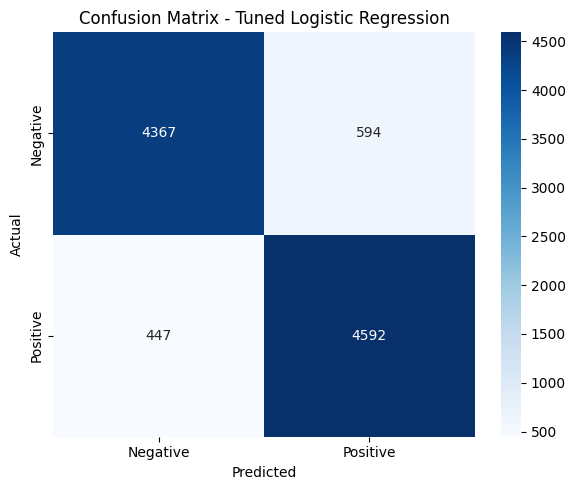

In [ ]:
cm = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Tuned Logistic Regression')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1833/1832991587.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='Accuracy', palette='viridis')


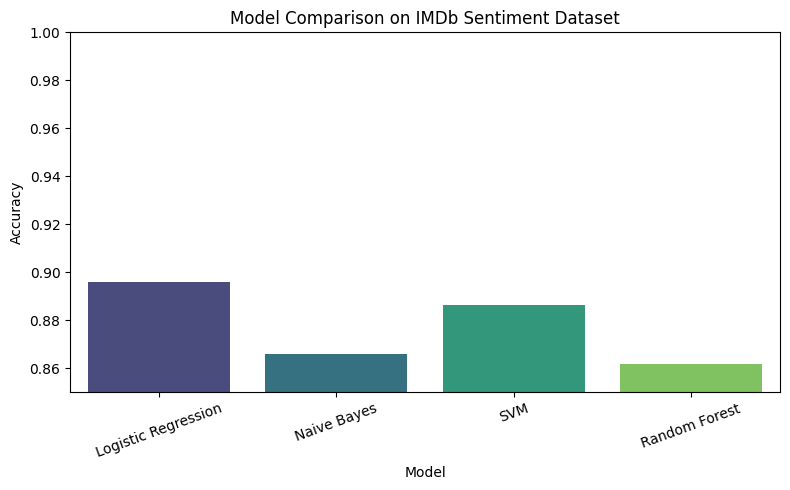

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x='Model', y='Accuracy', palette='viridis')
plt.title('Model Comparison on IMDb Sentiment Dataset')
plt.ylabel('Accuracy')
plt.ylim(0.85, 1.0)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
sample_reviews = [
    "This movie was absolutely wonderful, I loved every part of it.",
    "It was a complete disaster, the acting was terrible.",
    "The plot was decent but could have been better."
]

sample_clean = [clean_text(r) for r in sample_reviews]
sample_features = tfidf.transform(sample_clean)
predictions = best_model.predict(sample_features)

for review, pred in zip(sample_reviews, predictions):
    sentiment = "Positive" if pred == 1 else "Negative"
    print(f"Review: {review}")
    print(f"Predicted Sentiment: {sentiment}")
    print("-" * 60)

Review: This movie was absolutely wonderful, I loved every part of it.
Predicted Sentiment: Positive
------------------------------------------------------------
Review: It was a complete disaster, the acting was terrible.
Predicted Sentiment: Negative
------------------------------------------------------------
Review: The plot was decent but could have been better.
Predicted Sentiment: Negative
------------------------------------------------------------
